In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [3]:
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 8.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.6 MB/s eta 0:00:0000:01


In [4]:
from fastbook import *
from fastai.vision.widgets import *

In [5]:
key = os.environ.get('6e4b8b61648723b2049f28332500dfc3f3787400fdebede49307f329a127e6e9', 'XXX')

In [6]:
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

if iskaggle:
    !pip install -Uqq fastai 'duckduckgo_search>=6.2'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.9/242.9 kB 4.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.4/153.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 63.3 MB/s eta 0:00:00:00:010:01


In [7]:
!pip install -q -U ddgs
from ddgs import DDGS #DuckDuckGo has changed the api so we need to update 
from fastcore.all import L

def search_images(keywords, max_images=200):
    results = DDGS().images(
        keywords,
        max_results=max_images
    )
    return L(results).itemgot('image')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 1.5 MB/s eta 0:00:00


In [8]:
url = search_images('grizzly bear', max_images=200)
url[0]
#results = search_images_serpapi('grizzly bear', key=key)
#ims = results
len(url)

35

In [13]:
#ims = ['http://3.bp.blogspot.com/-S1scRCkI3vY/UHzV2kucsPI/AAAAAAAAA-k/YQ5UzHEm9Ss/s1600/Grizzly%2BBear%2BWildlife.jpg']

In [9]:
from fastdownload import download_url
dest = 'images/grizzly.jpg'
download_url(url[0], dest)

<div><progress max="129988" value="131072"></progress> 100.83% [131072/129988 00:00&lt;00:00]</div>

Path('images/grizzly.jpg')

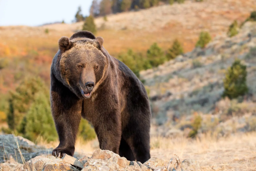

In [10]:
from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

In [11]:
bear_types = 'grizzly','black','teddy'
path = Path('bears')

for bear_type in bear_types:
    dest = path/bear_type
    dest.mkdir(exist_ok=True, parents=True)

    urls = search_images(f'{bear_type} bear photos', max_images=30)
    download_images(dest, urls=urls)

In [12]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)

[None]

In [13]:
bears = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(128)
)

dls = bears.dataloaders(path)

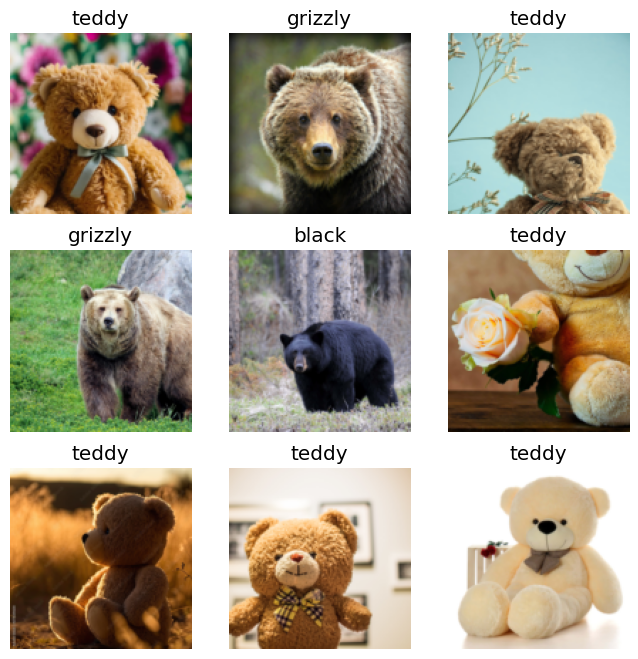

In [14]:
dls.show_batch(max_n=9, figsize=(8, 8))

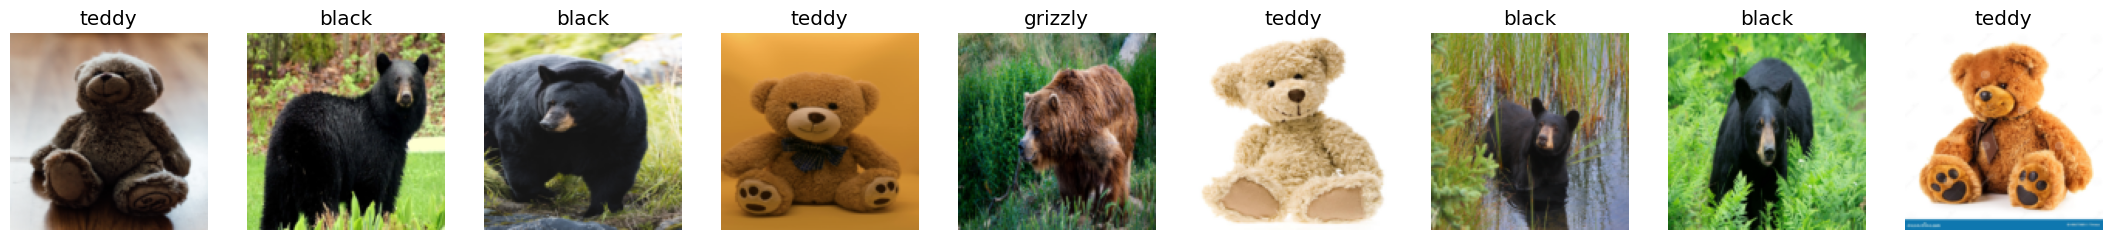

In [15]:
bears = bears.new(item_tfms=Resize(128, ResizeMethod.Squish))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=9, nrows=1)

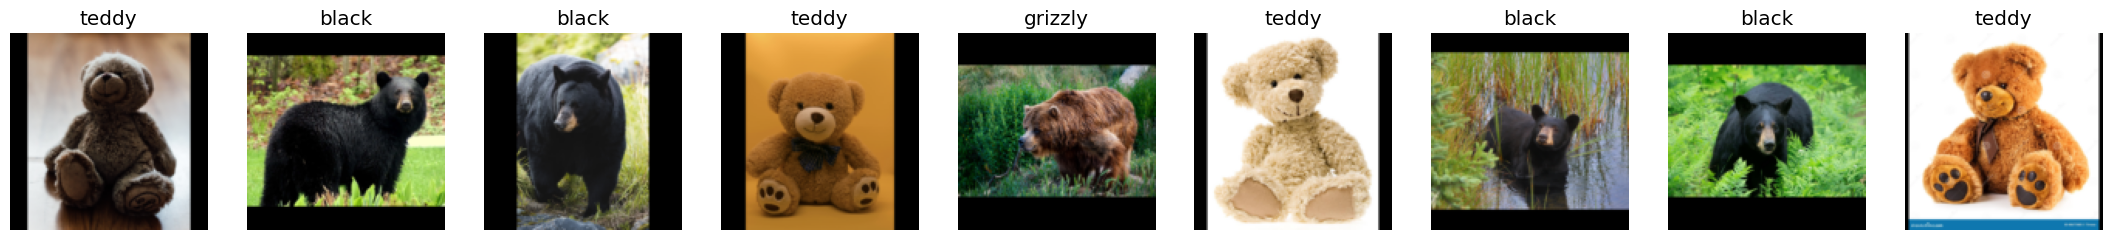

In [16]:
bears = bears.new(item_tfms=Resize(128, ResizeMethod.Pad, pad_mode='zeros'))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=9, nrows=1)

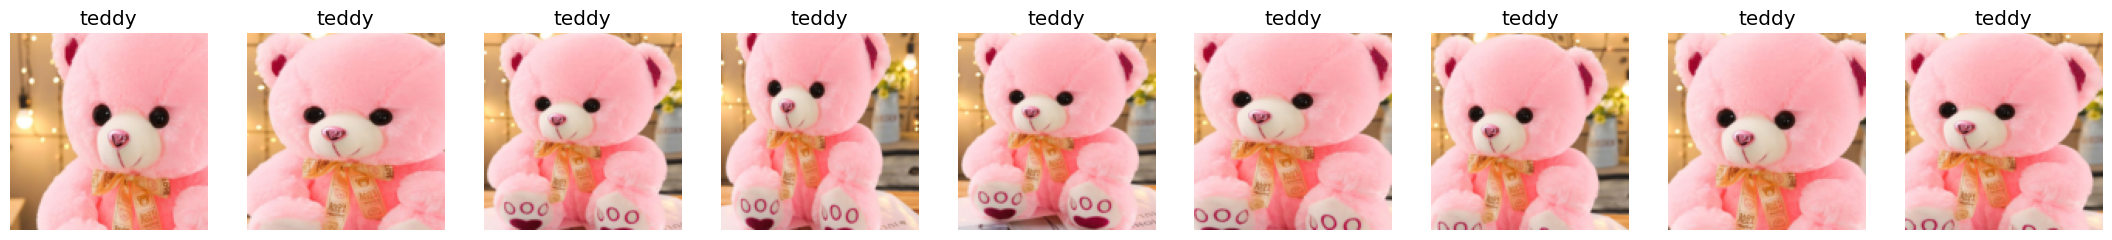

In [17]:
#Data Augmentation using RandomResizedCrop
bears = bears.new(item_tfms=RandomResizedCrop(128, min_scale=0.4))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=9, nrows=1, unique=True)

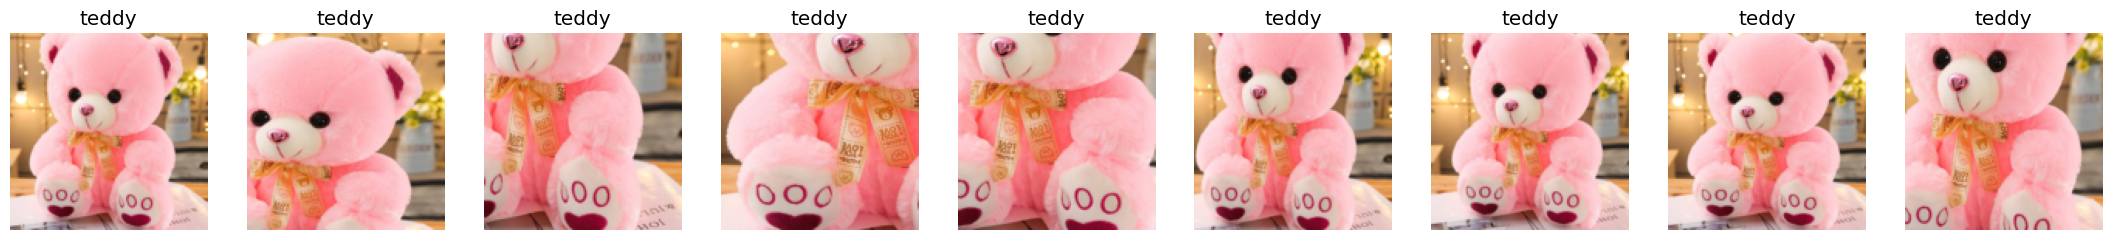

In [18]:
#Data Augmentation using RandomResizedCrop
bears = bears.new(item_tfms=RandomResizedCrop(128, min_scale=0.2))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=9, nrows=1, unique=True)

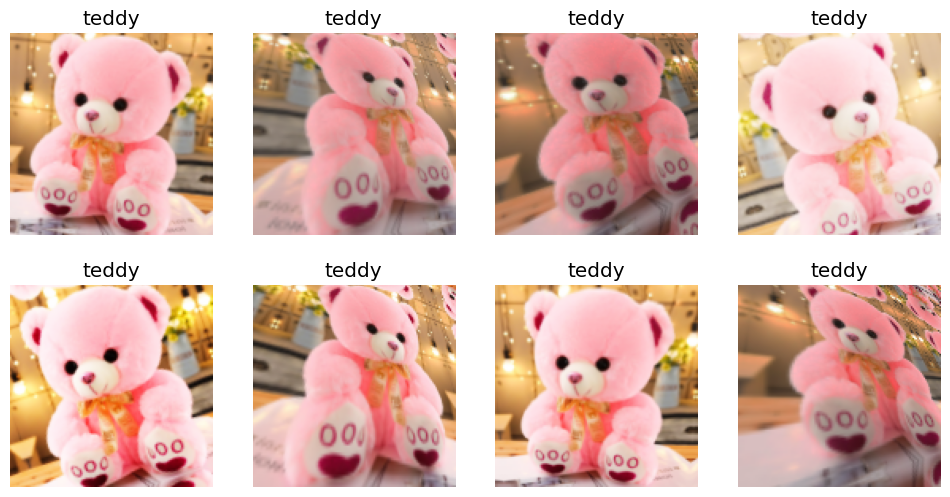

In [19]:
bears = bears.new(item_tfms=Resize(128), batch_tfms=aug_transforms(mult=2))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=8, nrows=2, unique=True)

In [20]:
bears = bears.new(
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms())
dls = bears.dataloaders(path)

In [22]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,2.108261,6.648639,0.750000,00:22


epoch,train_loss,valid_loss,error_rate,time
0,2.039286,4.362890,0.750000,00:25
1,1.738789,1.353036,0.625000,00:25
2,1.313099,0.278558,0.125000,00:25
3,1.003395,0.094344,0.000000,00:25


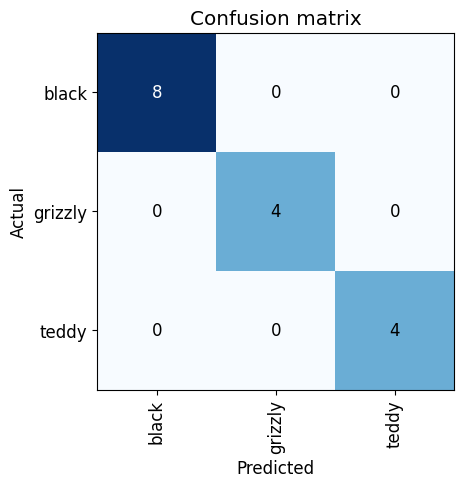

In [23]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

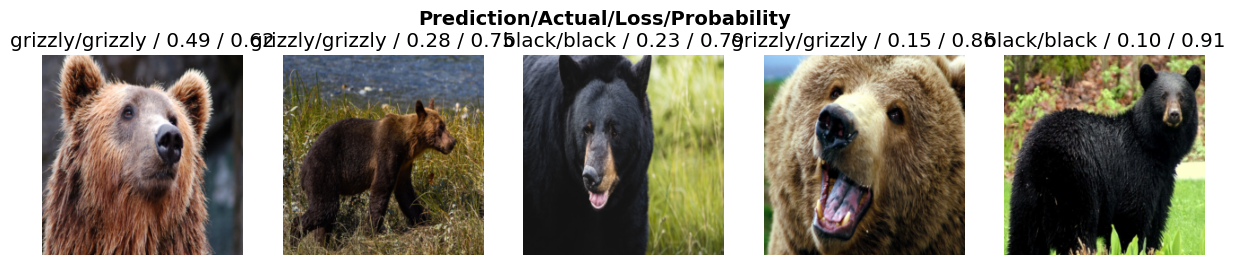

In [24]:
interp.plot_top_losses(5, nrows=1)

In [25]:
#hide_output
cleaner = ImageClassifierCleaner(learn)
cleaner

In [ ]:
#hide
#for idx in cleaner.delete(): cleaner.fns[idx].unlink()  #To delete (unlink) all images selected for deletion
#for idx,cat in cleaner.change(): shutil.move(str(cleaner.fns[idx]), path/cat) #To move images for which we've selected a different category

In [26]:
learn.export()

In [27]:
path = Path()
path.ls(file_exts='.pkl')

[Path('export.pkl')]

In [28]:
learn_inf = load_learner(path/'export.pkl')

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  try:


In [29]:

learn_inf.predict('images/grizzly.jpg')

('grizzly', tensor(1), tensor([0.1543, 0.7811, 0.0646]))

In [30]:
learn_inf.dls.vocab

['black', 'grizzly', 'teddy']

In [31]:
#hide_output
btn_upload = widgets.FileUpload()
btn_upload

FileUpload(value=(), description='Upload')

In [42]:
btn_upload = SimpleNamespace(data = ['images/grizzly.jpg'])

In [43]:
img = PILImage.create(btn_upload.data[-1])

In [44]:
#hide_output
out_pl = widgets.Output()
out_pl.clear_output()
with out_pl: display(img.to_thumb(128,128))
out_pl

Output()

In [45]:

pred,pred_idx,probs = learn_inf.predict(img)

In [46]:
#hide_output
lbl_pred = widgets.Label()
lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'
lbl_pred

Label(value='Prediction: grizzly; Probability: 0.7811')

In [38]:
#hide_output
btn_run = widgets.Button(description='Classify')
btn_run

Button(description='Classify', style=ButtonStyle())

In [39]:
def on_click_classify(change):
    img = PILImage.create(btn_upload.data[-1])
    out_pl.clear_output()
    with out_pl: display(img.to_thumb(128,128))
    pred,pred_idx,probs = learn_inf.predict(img)
    lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'

btn_run.on_click(on_click_classify)

In [40]:
#hide
#Putting back btn_upload to a widget for next cell
btn_upload = widgets.FileUpload()

In [41]:
#hide_output
VBox([widgets.Label('Select your bear!'), 
      btn_upload, btn_run, out_pl, lbl_pred])